# PN-TDNN-DPD Training: CWGAN-GP with QAT

**Version:** 2.0 (Production)  
**Architecture:** Phase-Normalized TDNN (24-dim, M=3, 1,362 params)  
**Training:** CWGAN-GP + Spectral Loss + ILA  

## Key Design Decisions

| Component | Specification | Reason |
|-----------|--------------|--------|
| Input dim | 24 | 6 features × 4 taps (M=3) |
| Memory depth | M=3 | Captures >95% GaN PA memory |
| Feature extraction | Phase-normalized | Decouples amplitude/phase learning |
| Output activation | Linear (no Tanh) | Phase denorm bounds output naturally |
| Training | ILA | No PA model in loop |
| QAT | Q1.15 weights, Q8.8 activations | After epoch 300 |

In [1]:
# Install dependencies (run once)
!pip install -q torch torchvision torchaudio
!pip install -q numpy pandas matplotlib seaborn tqdm
!pip install -q scipy scikit-learn pyyaml tensorboard

print("✅ Dependencies installed!")

✅ Dependencies installed!


In [3]:
# Cell 1: Environment Setup
import os
import sys
from pathlib import Path

# Check if running in Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

else:
    # Local development
    REPO_PATH = Path('.').resolve()
    sys.path.insert(0, str(REPO_PATH))

Mounted at /content/drive


In [4]:
# Set working directory
WORK_DIR = '/content/drive/MyDrive/FIX/6g-pa-gan-dpd' #change MyDrive to Revised as branch in gdrive
os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)

In [5]:
REPO_PATH = Path('/content/drive/MyDrive/FIX/6g-pa-gan-dpd')
print(f"Working directory: {os.getcwd()}")
print(f"Python path includes: {REPO_PATH}")

Working directory: /content/drive/MyDrive/FIX/6g-pa-gan-dpd
Python path includes: /content/drive/MyDrive/FIX/6g-pa-gan-dpd


In [11]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
import yaml
from typing import Dict, Tuple
from torch.utils.tensorboard import SummaryWriter

from models.pn_tdnn_generator import (
    PNTDNNGenerator,
    PhaseNormalizedFeatureExtraction,
    Discriminator,
    create_pn_tdnn_generator,
    create_discriminator
)
from utils.spectral_loss import SpectralLoss

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU: Tesla T4
  Memory: 15.8 GB


In [7]:
# Cell 3: Configuration (matches train.py and ARCHITECTURE.md)
config = {
    # Model architecture (FROZEN - matches ARCHITECTURE.md)
    'model': {
        'generator': {
            'memory_depth': 3,        # M=3 (24-dim input)
            'hidden_dims': [32, 16],  # FC layers
            'leaky_slope': 0.2,       # LeakyReLU
        },
        'discriminator': {
            'input_dim': 4,           # 2 (output) + 2 (condition)
            'hidden_dims': [64, 32],  # FC layers
            'leaky_slope': 0.2,
        }
    },

    # Dataset configuration (dpa_200mhz)
    'dataset': {
        'name': 'DPA_200MHz',
        'n_channels': 1,              # CHANGED: 1 channel (was 5 for apa_200mhz)
        'n_sub_channels': 10,         # CHANGED: 10 sub-channels (was 1 for apa_200mhz)
    },

    # Training hyperparameters
    'training': {
        'epochs': 500,
        'batch_size': 64,
        'n_critic': 5,                # WGAN-GP: train D 5x per G update
        'gp_weight': 10.0,            # Gradient penalty weight

        'optimizer': {
            'lr_generator': 1e-4,
            'lr_discriminator': 1e-4,
            'betas': [0.0, 0.9],      # WGAN-GP: no momentum
            'weight_decay': 1e-5,
        },

        'scheduler': {
            'type': 'cosine',
            'min_lr': 1e-6,
        },

        'loss': {
            'adversarial': 1.0,       # Wasserstein loss weight
            'reconstruction_l1': 50.0, # L1 loss weight
            'spectral': 10.0,         # Spectral loss weight
        },
    },

    # Early stopping configuration (NEW)
    'early_stopping': {
        'enabled': True,              # Enable early stopping
        'patience': 25,               # Stop if no improvement for 25 epochs
        'monitor': 'val_evm_db',      # Metric to monitor ('val_evm_db', 'val_nmse_db', 'val_l1')
        'min_delta': 0.01,            # Minimum improvement threshold (0.01 dB for EVM)
        'restore_best_weights': True, # Restore best model at end
    },

    # QAT configuration
    'qat': {
        'enabled': True,
        'start_epoch': 300,           # Enable QAT after float32 pre-training
        'weight_bits': 16,            # Q1.15
        'activation_bits': 16,        # Q8.8
    },

    # System parameters (CHANGED for dpa_200mhz)
    'system': {
        'sample_rate': 800e6,         # CHANGED: 200 MSps for dpa_200mhz (was 250 MSps)
    },

    # Spectral loss configuration (CRITICAL for dpa_200mhz)
    'spectral_loss': {
        'bw_main_ch': 200e6,          # Main channel 200 MHz
        'n_sub_ch': 10,               # CHANGED: 10 sub-channels for dpa_200mhz
        'nperseg': 2560,              # FFT segment length
    },

    # Logging
    'logging': {
        'log_interval': 100,
        'checkpoint_interval': 25,
    }
}

print("Configuration loaded:")
print(f"  Dataset: {config['dataset']['name']} ({config['dataset']['n_channels']} channel, {config['dataset']['n_sub_channels']} sub-channels)")
print(f"  Sample rate: {config['system']['sample_rate']/1e6:.0f} MSps")
print(f"  Memory depth: M={config['model']['generator']['memory_depth']}")
print(f"  Input dim: {6 * (config['model']['generator']['memory_depth'] + 1)}")
print(f"  Hidden dims: {config['model']['generator']['hidden_dims']}")
print(f"  Epochs: {config['training']['epochs']}")
print(f"  QAT starts at epoch: {config['qat']['start_epoch']}")
print(f"  Spectral Loss: {config['spectral_loss']['n_sub_ch']} sub-channels, {config['spectral_loss']['bw_main_ch']/1e6:.0f} MHz BW")
print(f"  Early Stopping: {config['early_stopping']['enabled']} (patience={config['early_stopping']['patience']}, monitor={config['early_stopping']['monitor']})")

Configuration loaded:
  Dataset: DPA_200MHz (1 channel, 10 sub-channels)
  Sample rate: 800 MSps
  Memory depth: M=3
  Input dim: 24
  Hidden dims: [32, 16]
  Epochs: 500
  QAT starts at epoch: 300
  Spectral Loss: 10 sub-channels, 200 MHz BW
  Early Stopping: True (patience=25, monitor=val_evm_db)


In [8]:
# Cell 4: Data Loading (matches train.py)
def load_measured_data(data_dir: Path, split: str = 'train'):
    """
    Load measured PA input/output data from CSV files.

    ILA convention:
    - u_pa: PA input (clean signal) -> TARGET for DPD
    - y_pa: PA output (distorted signal) -> INPUT to DPD
    """
    input_file = data_dir / f'{split}_input.csv'
    output_file = data_dir / f'{split}_output.csv'

    if not input_file.exists() or not output_file.exists():
        raise FileNotFoundError(f"Data files not found in {data_dir}")

    # Load CSV files
    input_df = pd.read_csv(input_file)
    output_df = pd.read_csv(output_file)

    # Convert to complex arrays
    u_pa = (input_df['I'].values + 1j * input_df['Q'].values).astype(np.complex64)
    y_pa = (output_df['I'].values + 1j * output_df['Q'].values).astype(np.complex64)

    # Normalize to -3 dBFS (0.7 linear)
    max_val = np.max(np.abs(u_pa))
    u_pa = u_pa / max_val * 0.7
    y_pa = y_pa / max_val * 0.7

    print(f"Loaded {len(u_pa):,} {split} samples")
    print(f"  PA input power:  {10*np.log10(np.mean(np.abs(u_pa)**2)):.2f} dBFS")
    print(f"  PA output power: {10*np.log10(np.mean(np.abs(y_pa)**2)):.2f} dBFS")

    return u_pa, y_pa

# Load data
data_dir = Path('data/DPA_200MHz')
u_pa_train, y_pa_train = load_measured_data(data_dir, 'train')
u_pa_val, y_pa_val = load_measured_data(data_dir, 'val')
u_pa_test, y_pa_test = load_measured_data(data_dir, 'test')

Loaded 23,040 train samples
  PA input power:  -12.31 dBFS
  PA output power: -2.26 dBFS
Loaded 7,680 val samples
  PA input power:  -12.20 dBFS
  PA output power: -2.19 dBFS
Loaded 7,680 test samples
  PA input power:  -11.80 dBFS
  PA output power: -1.77 dBFS


In [9]:
# Cell 5: Dataset Creation (matches train.py)
def create_dpd_dataset(u_pa: np.ndarray, y_pa: np.ndarray, memory_depth: int = 3) -> TensorDataset:
    """
    Create dataset for DPD training using Indirect Learning Architecture.

    ILA: DPD(y_PA) ≈ u_PA
    - Input to DPD: y_PA (distorted PA output)
    - Target: u_PA (clean PA input)

    PNTDNNGenerator handles phase-normalized feature extraction internally.
    We return raw IQ sequences [batch, M+1, 2].
    """
    num_samples = len(y_pa) - memory_depth

    # Input: raw IQ sequences from PA output
    inputs = np.zeros((num_samples, memory_depth + 1, 2), dtype=np.float32)
    # Target: IQ samples from PA input
    targets = np.zeros((num_samples, 2), dtype=np.float32)

    for i in range(num_samples):
        # Memory taps from PA output (time order: oldest to newest)
        for m in range(memory_depth + 1):
            idx = i + memory_depth - m
            inputs[i, m, 0] = y_pa[idx].real
            inputs[i, m, 1] = y_pa[idx].imag

        # Target is PA input at current time
        target_idx = i + memory_depth
        targets[i, 0] = u_pa[target_idx].real
        targets[i, 1] = u_pa[target_idx].imag

    return TensorDataset(torch.from_numpy(inputs), torch.from_numpy(targets))

# Create datasets
memory_depth = config['model']['generator']['memory_depth']
train_dataset = create_dpd_dataset(u_pa_train, y_pa_train, memory_depth)
val_dataset = create_dpd_dataset(u_pa_val, y_pa_val, memory_depth)
test_dataset = create_dpd_dataset(u_pa_test, y_pa_test, memory_depth)

# Create dataloaders
batch_size = config['training']['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataset sizes:")
print(f"  Training:   {len(train_dataset):,} samples, {len(train_loader):,} batches")
print(f"  Validation: {len(val_dataset):,} samples, {len(val_loader):,} batches")
print(f"  Test:       {len(test_dataset):,} samples, {len(test_loader):,} batches")


Dataset sizes:
  Training:   23,037 samples, 359 batches
  Validation: 7,677 samples, 120 batches
  Test:       7,677 samples, 120 batches


Loaded 23,040 train samples
  PA input power:  -12.31 dBFS
  PA output power: -2.26 dBFS
Loaded 7,680 val samples
  PA input power:  -12.20 dBFS
  PA output power: -2.19 dBFS


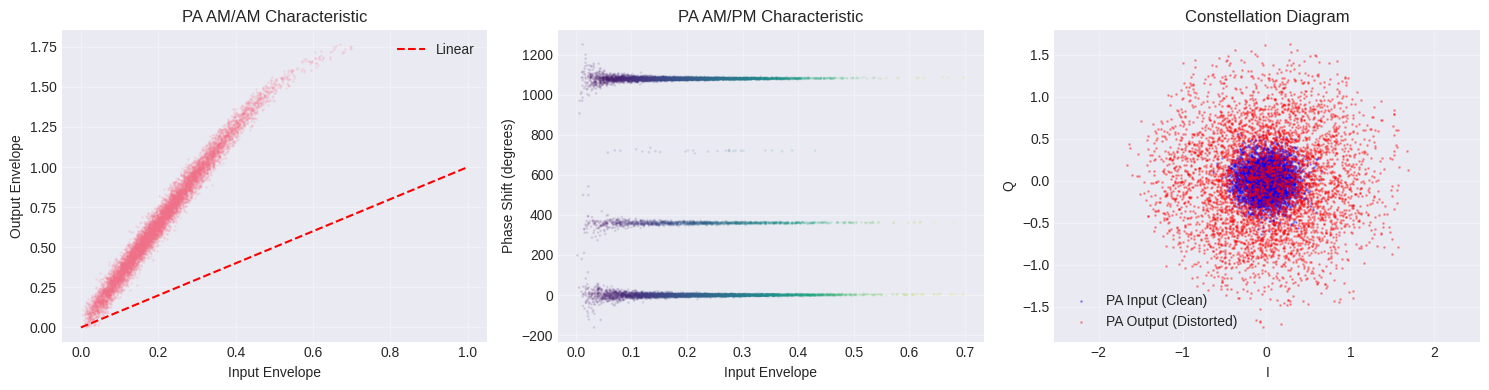


✅ Data loaded successfully!
   Training samples: 23,040
   Validation samples: 7,680


In [13]:
# # Cell 5a: PA Distortion and IQ Signal Visualization

try:
    u_pa_train, y_pa_train = load_measured_data(data_dir, 'train')
    u_pa_val, y_pa_val = load_measured_data(data_dir, 'val')

    # Quick visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # AM/AM characteristic
    env_in = np.abs(u_pa_train[:10000])
    env_out = np.abs(y_pa_train[:10000])
    axes[0].scatter(env_in, env_out, alpha=0.1, s=1)
    axes[0].plot([0, 1], [0, 1], 'r--', label='Linear')
    axes[0].set_xlabel('Input Envelope')
    axes[0].set_ylabel('Output Envelope')
    axes[0].set_title('PA AM/AM Characteristic')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # AM/PM characteristic
    phase_in = np.angle(u_pa_train[:10000])
    phase_out = np.angle(y_pa_train[:10000])
    phase_diff = np.unwrap(phase_out - phase_in)
    axes[1].scatter(env_in, np.degrees(phase_diff), alpha=0.1, s=1, c=env_in, cmap='viridis')
    axes[1].set_xlabel('Input Envelope')
    axes[1].set_ylabel('Phase Shift (degrees)')
    axes[1].set_title('PA AM/PM Characteristic')
    axes[1].grid(True, alpha=0.3)

    # Constellation
    axes[2].scatter(u_pa_train[:5000].real, u_pa_train[:5000].imag,
                   alpha=0.3, s=1, label='PA Input (Clean)', c='blue')
    axes[2].scatter(y_pa_train[:5000].real, y_pa_train[:5000].imag,
                   alpha=0.3, s=1, label='PA Output (Distorted)', c='red')
    axes[2].set_xlabel('I')
    axes[2].set_ylabel('Q')
    axes[2].set_title('Constellation Diagram')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].axis('equal')

    plt.tight_layout()
    plt.savefig('figures/pa_characteristics.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Data loaded successfully!")
    print(f"   Training samples: {len(u_pa_train):,}")
    print(f"   Validation samples: {len(u_pa_val):,}")

except FileNotFoundError as e:
    print(f"\n❌ {e}")
    print("\nℹ️ Please upload your OpenDPD data files to the 'data' directory!")

Computing spectral analysis with 10 subchannels...


/tmp/ipython-input-1328438839.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power_linear = np.trapz(psd[mask], freqs[mask])


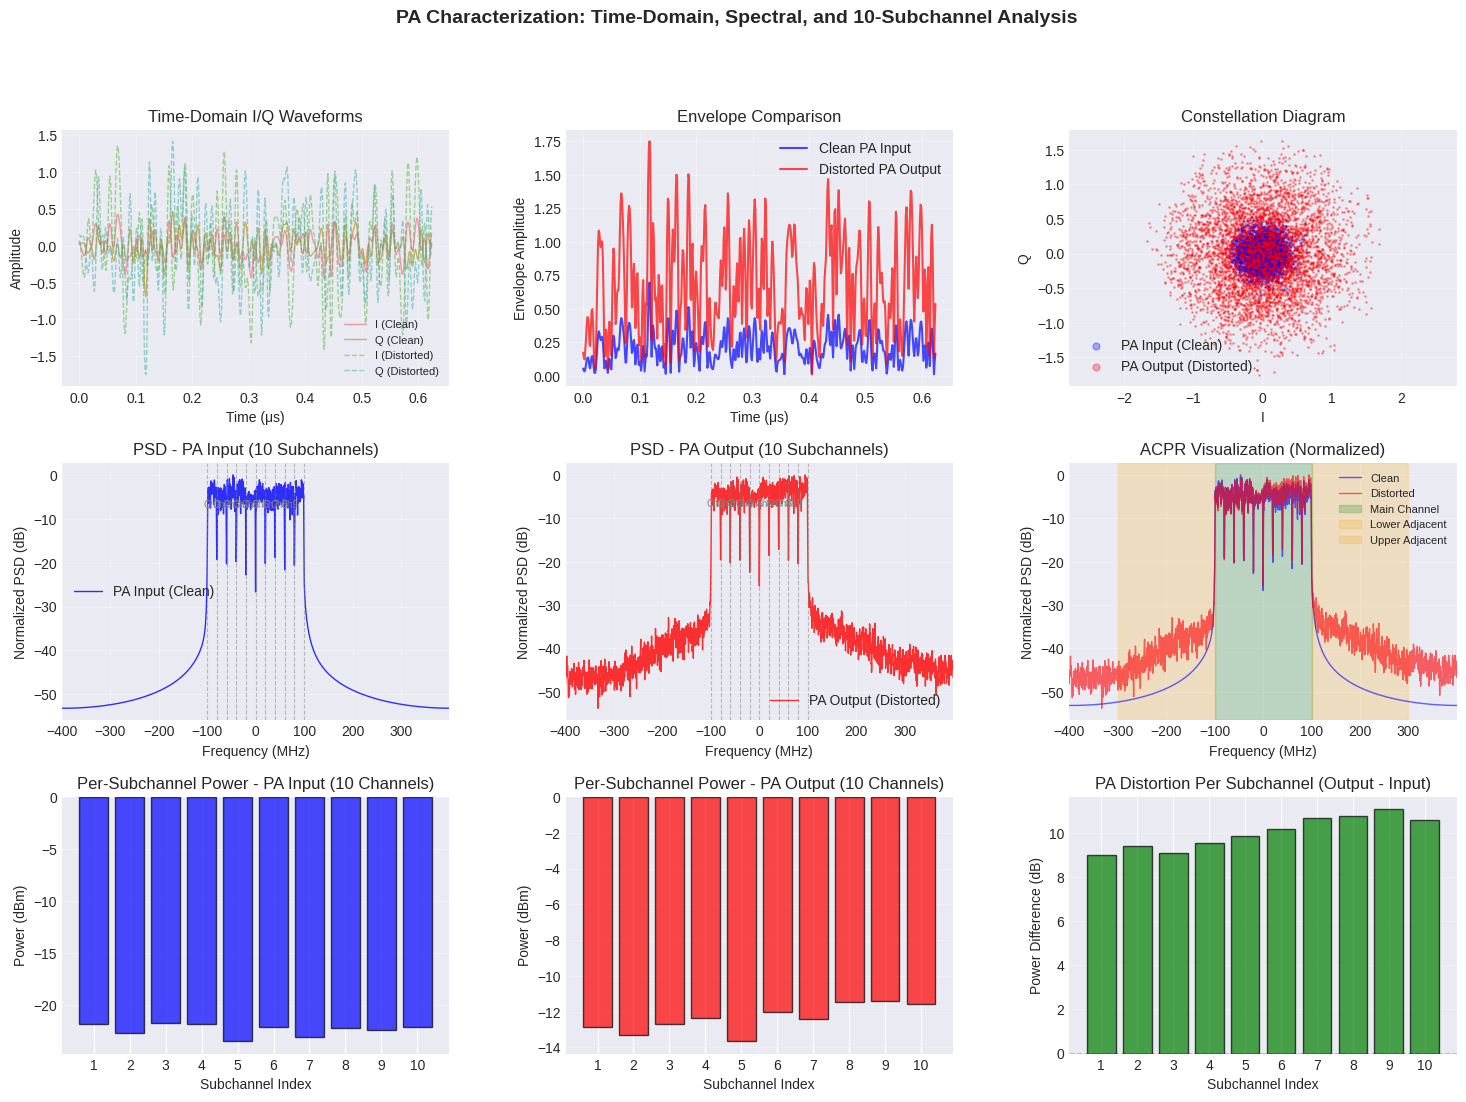


✅ Comprehensive visualization complete!
   Sample rate: 800 MSps
   Main channel BW: 200 MHz
   Subchannels: 10
   Subchannel BW: 20.0 MHz

   Mean power (Clean):     -22.37 dBm
   Mean power (Distorted): -12.37 dBm
   Power difference:       10.00 dB


In [14]:
# Cell 5b: Comprehensive Visualization - Time Domain, Spectral, and Per-Subchannel Analysis
from scipy import signal as scipy_signal
from scipy.fft import fft, fftfreq, fftshift

def compute_psd_with_subchannels(signal_data, fs, nperseg=2560, n_sub_ch=10, bw_main_ch=200e6):
    """
    Compute PSD and identify subchannel boundaries.

    Args:
        signal_data: Complex time-domain signal
        fs: Sample rate (Hz)
        nperseg: FFT segment length
        n_sub_ch: Number of subchannels
        bw_main_ch: Main channel bandwidth (Hz)

    Returns:
        freqs: Frequency vector (Hz)
        psd_db: PSD in dBm/Hz
        subchannel_edges: List of (f_start, f_end) for each subchannel
    """
    # Compute PSD using Welch's method
    freqs, psd = scipy_signal.welch(signal_data, fs=fs, nperseg=nperseg,
                                     scaling='density', return_onesided=False)

    # Shift to centered spectrum
    freqs = fftshift(freqs)
    psd = fftshift(psd)

    # Convert to dBm/Hz (assuming 50 ohm impedance)
    psd_db = 10 * np.log10(psd + 1e-20)  # Add small value to avoid log(0)

    # Compute subchannel edges
    subchannel_bw = bw_main_ch / n_sub_ch
    f_start = -bw_main_ch / 2
    subchannel_edges = []
    for i in range(n_sub_ch):
        f_low = f_start + i * subchannel_bw
        f_high = f_low + subchannel_bw
        subchannel_edges.append((f_low, f_high))

    return freqs, psd_db, subchannel_edges

def compute_subchannel_power(signal_data, fs, subchannel_edges, nperseg=2560):
    """
    Compute power in each subchannel.

    Args:
        signal_data: Complex time-domain signal
        fs: Sample rate (Hz)
        subchannel_edges: List of (f_start, f_end) tuples
        nperseg: FFT segment length

    Returns:
        subchannel_powers: Array of power in dBm for each subchannel
    """
    freqs, psd = scipy_signal.welch(signal_data, fs=fs, nperseg=nperseg,
                                     scaling='density', return_onesided=False)
    freqs = fftshift(freqs)
    psd = fftshift(psd)

    subchannel_powers = []
    for f_low, f_high in subchannel_edges:
        # Find indices within subchannel
        mask = (freqs >= f_low) & (freqs <= f_high)
        # Integrate PSD over subchannel bandwidth
        power_linear = np.trapz(psd[mask], freqs[mask])
        power_dbm = 10 * np.log10(power_linear + 1e-20)
        subchannel_powers.append(power_dbm)

    return np.array(subchannel_powers)

# Visualization parameters
fs = config['system']['sample_rate']  # 800e6 Hz
nperseg = config['spectral_loss']['nperseg']  # 2560
n_sub_ch = config['spectral_loss']['n_sub_ch']  # 10
bw_main_ch = config['spectral_loss']['bw_main_ch']  # 200e6 Hz

# Sample subset for visualization
n_samples = 10000
u_pa_vis = u_pa_train[:n_samples]
y_pa_vis = y_pa_train[:n_samples]

print("Computing spectral analysis with 10 subchannels...")

# Compute PSD and subchannel boundaries
freqs_clean, psd_clean, subchannel_edges = compute_psd_with_subchannels(
    u_pa_vis, fs, nperseg, n_sub_ch, bw_main_ch
)
freqs_distorted, psd_distorted, _ = compute_psd_with_subchannels(
    y_pa_vis, fs, nperseg, n_sub_ch, bw_main_ch
)

# Compute per-subchannel power
power_clean = compute_subchannel_power(u_pa_vis, fs, subchannel_edges, nperseg)
power_distorted = compute_subchannel_power(y_pa_vis, fs, subchannel_edges, nperseg)

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ===========================
# Row 1: Time-Domain Analysis
# ===========================

# Time-domain I/Q waveforms
ax1 = fig.add_subplot(gs[0, 0])
t_us = np.arange(500) / (fs / 1e6)  # First 500 samples in microseconds
ax1.plot(t_us, u_pa_vis[:500].real, label='I (Clean)', alpha=0.7, linewidth=1)
ax1.plot(t_us, u_pa_vis[:500].imag, label='Q (Clean)', alpha=0.7, linewidth=1)
ax1.plot(t_us, y_pa_vis[:500].real, label='I (Distorted)', alpha=0.5, linewidth=1, linestyle='--')
ax1.plot(t_us, y_pa_vis[:500].imag, label='Q (Distorted)', alpha=0.5, linewidth=1, linestyle='--')
ax1.set_xlabel('Time (μs)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Time-Domain I/Q Waveforms')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Envelope comparison
ax2 = fig.add_subplot(gs[0, 1])
env_clean = np.abs(u_pa_vis[:500])
env_distorted = np.abs(y_pa_vis[:500])
ax2.plot(t_us, env_clean, label='Clean PA Input', alpha=0.7, linewidth=1.5, color='blue')
ax2.plot(t_us, env_distorted, label='Distorted PA Output', alpha=0.7, linewidth=1.5, color='red')
ax2.set_xlabel('Time (μs)')
ax2.set_ylabel('Envelope Amplitude')
ax2.set_title('Envelope Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Constellation diagram
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(u_pa_vis[:5000].real, u_pa_vis[:5000].imag,
           alpha=0.3, s=1, label='PA Input (Clean)', c='blue')
ax3.scatter(y_pa_vis[:5000].real, y_pa_vis[:5000].imag,
           alpha=0.3, s=1, label='PA Output (Distorted)', c='red')
ax3.set_xlabel('I')
ax3.set_ylabel('Q')
ax3.set_title('Constellation Diagram')
ax3.legend(markerscale=5)
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

# ===========================
# Row 2: Spectral Analysis with Subchannels
# ===========================

# Create normalized versions (0 dB peak)
psd_clean_norm = psd_clean - np.max(psd_clean)
psd_distorted_norm = psd_distorted - np.max(psd_distorted)

# PSD with subchannel boundaries (Clean)
ax4 = fig.add_subplot(gs[1, 0])
freqs_mhz = freqs_clean / 1e6
# CHANGE 1: Use psd_clean_norm instead of psd_clean
ax4.plot(freqs_mhz, psd_clean_norm, label='PA Input (Clean)', color='blue', linewidth=1, alpha=0.8)
# Mark subchannel boundaries
for i, (f_low, f_high) in enumerate(subchannel_edges):
    ax4.axvline(x=f_low/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    if i < len(subchannel_edges) - 1:
        # Dynamic text positioning will work fine with normalized data (0 - 10 = -10 dB)
        ax4.text((f_low + f_high) / 2 / 1e6, ax4.get_ylim()[1] - 10,
                f'Ch{i+1}', ha='center', fontsize=7, color='gray')
ax4.axvline(x=subchannel_edges[-1][1]/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax4.set_xlabel('Frequency (MHz)')
# CHANGE 2: Update label to 'Normalized PSD (dB)'
ax4.set_ylabel('Normalized PSD (dB)')
ax4.set_title(f'PSD - PA Input ({n_sub_ch} Subchannels)')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim([freqs_mhz[0], freqs_mhz[-1]])

# PSD with subchannel boundaries (Distorted)
ax5 = fig.add_subplot(gs[1, 1])
# CHANGE 3: Use psd_distorted_norm instead of psd_distorted
ax5.plot(freqs_mhz, psd_distorted_norm, label='PA Output (Distorted)', color='red', linewidth=1, alpha=0.8)
# Mark subchannel boundaries
for i, (f_low, f_high) in enumerate(subchannel_edges):
    ax5.axvline(x=f_low/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    if i < len(subchannel_edges) - 1:
        ax5.text((f_low + f_high) / 2 / 1e6, ax5.get_ylim()[1] - 10,
                f'Ch{i+1}', ha='center', fontsize=7, color='gray')
ax5.axvline(x=subchannel_edges[-1][1]/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax5.set_xlabel('Frequency (MHz)')
# CHANGE 4: Update label
ax5.set_ylabel('Normalized PSD (dB)')
ax5.set_title(f'PSD - PA Output ({n_sub_ch} Subchannels)')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_xlim([freqs_mhz[0], freqs_mhz[-1]])

# PSD Overlay for ACPR visualization
ax6 = fig.add_subplot(gs[1, 2])
# CHANGE 5 & 6: Use normalized versions for both
ax6.plot(freqs_mhz, psd_clean_norm, label='Clean', color='blue', linewidth=1, alpha=0.6)
ax6.plot(freqs_mhz, psd_distorted_norm, label='Distorted', color='red', linewidth=1, alpha=0.6)
# Highlight main channel and adjacent channels
main_ch_mask = (freqs_clean >= -bw_main_ch/2) & (freqs_clean <= bw_main_ch/2)
adj_lower_mask = (freqs_clean >= -3*bw_main_ch/2) & (freqs_clean < -bw_main_ch/2)
adj_upper_mask = (freqs_clean > bw_main_ch/2) & (freqs_clean <= 3*bw_main_ch/2)
ax6.axvspan(-bw_main_ch/2/1e6, bw_main_ch/2/1e6, alpha=0.2, color='green', label='Main Channel')
ax6.axvspan(-3*bw_main_ch/2/1e6, -bw_main_ch/2/1e6, alpha=0.2, color='orange', label='Lower Adjacent')
ax6.axvspan(bw_main_ch/2/1e6, 3*bw_main_ch/2/1e6, alpha=0.2, color='orange', label='Upper Adjacent')
ax6.set_xlabel('Frequency (MHz)')
ax6.set_ylabel('Normalized PSD (dB)')
ax6.set_title('ACPR Visualization (Normalized)')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)
ax6.set_xlim([freqs_mhz[0], freqs_mhz[-1]])
# Optional: Set Y-limit to focus on the top 80dB dynamic range
# ax6.set_ylim([-80, 5])

# ===========================
# Row 3: Per-Subchannel Analysis
# ===========================

# Per-subchannel power (Clean)
ax7 = fig.add_subplot(gs[2, 0])
subchannel_idx = np.arange(1, n_sub_ch + 1)
ax7.bar(subchannel_idx, power_clean, alpha=0.7, color='blue', edgecolor='black')
ax7.set_xlabel('Subchannel Index')
ax7.set_ylabel('Power (dBm)')
ax7.set_title(f'Per-Subchannel Power - PA Input ({n_sub_ch} Channels)')
ax7.grid(True, alpha=0.3, axis='y')
ax7.set_xticks(subchannel_idx)

# Per-subchannel power (Distorted)
ax8 = fig.add_subplot(gs[2, 1])
ax8.bar(subchannel_idx, power_distorted, alpha=0.7, color='red', edgecolor='black')
ax8.set_xlabel('Subchannel Index')
ax8.set_ylabel('Power (dBm)')
ax8.set_title(f'Per-Subchannel Power - PA Output ({n_sub_ch} Channels)')
ax8.grid(True, alpha=0.3, axis='y')
ax8.set_xticks(subchannel_idx)

# Per-subchannel power difference (Distortion)
ax9 = fig.add_subplot(gs[2, 2])
power_diff = power_distorted - power_clean
colors = ['green' if d > 0 else 'purple' for d in power_diff]
ax9.bar(subchannel_idx, power_diff, alpha=0.7, color=colors, edgecolor='black')
ax9.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax9.set_xlabel('Subchannel Index')
ax9.set_ylabel('Power Difference (dB)')
ax9.set_title(f'PA Distortion Per Subchannel (Output - Input)')
ax9.grid(True, alpha=0.3, axis='y')
ax9.set_xticks(subchannel_idx)

plt.suptitle(f'PA Characterization: Time-Domain, Spectral, and {n_sub_ch}-Subchannel Analysis',
             fontsize=14, fontweight='bold')

plt.savefig('figures/pa_comprehensive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Comprehensive visualization complete!")
print(f"   Sample rate: {fs/1e6:.0f} MSps")
print(f"   Main channel BW: {bw_main_ch/1e6:.0f} MHz")
print(f"   Subchannels: {n_sub_ch}")
print(f"   Subchannel BW: {bw_main_ch/n_sub_ch/1e6:.1f} MHz")
print(f"\n   Mean power (Clean):     {np.mean(power_clean):.2f} dBm")
print(f"   Mean power (Distorted): {np.mean(power_distorted):.2f} dBm")
print(f"   Power difference:       {np.mean(power_diff):.2f} dB")

Performing reverse DSP chain with FFT, subcarrier extraction, and equalization...


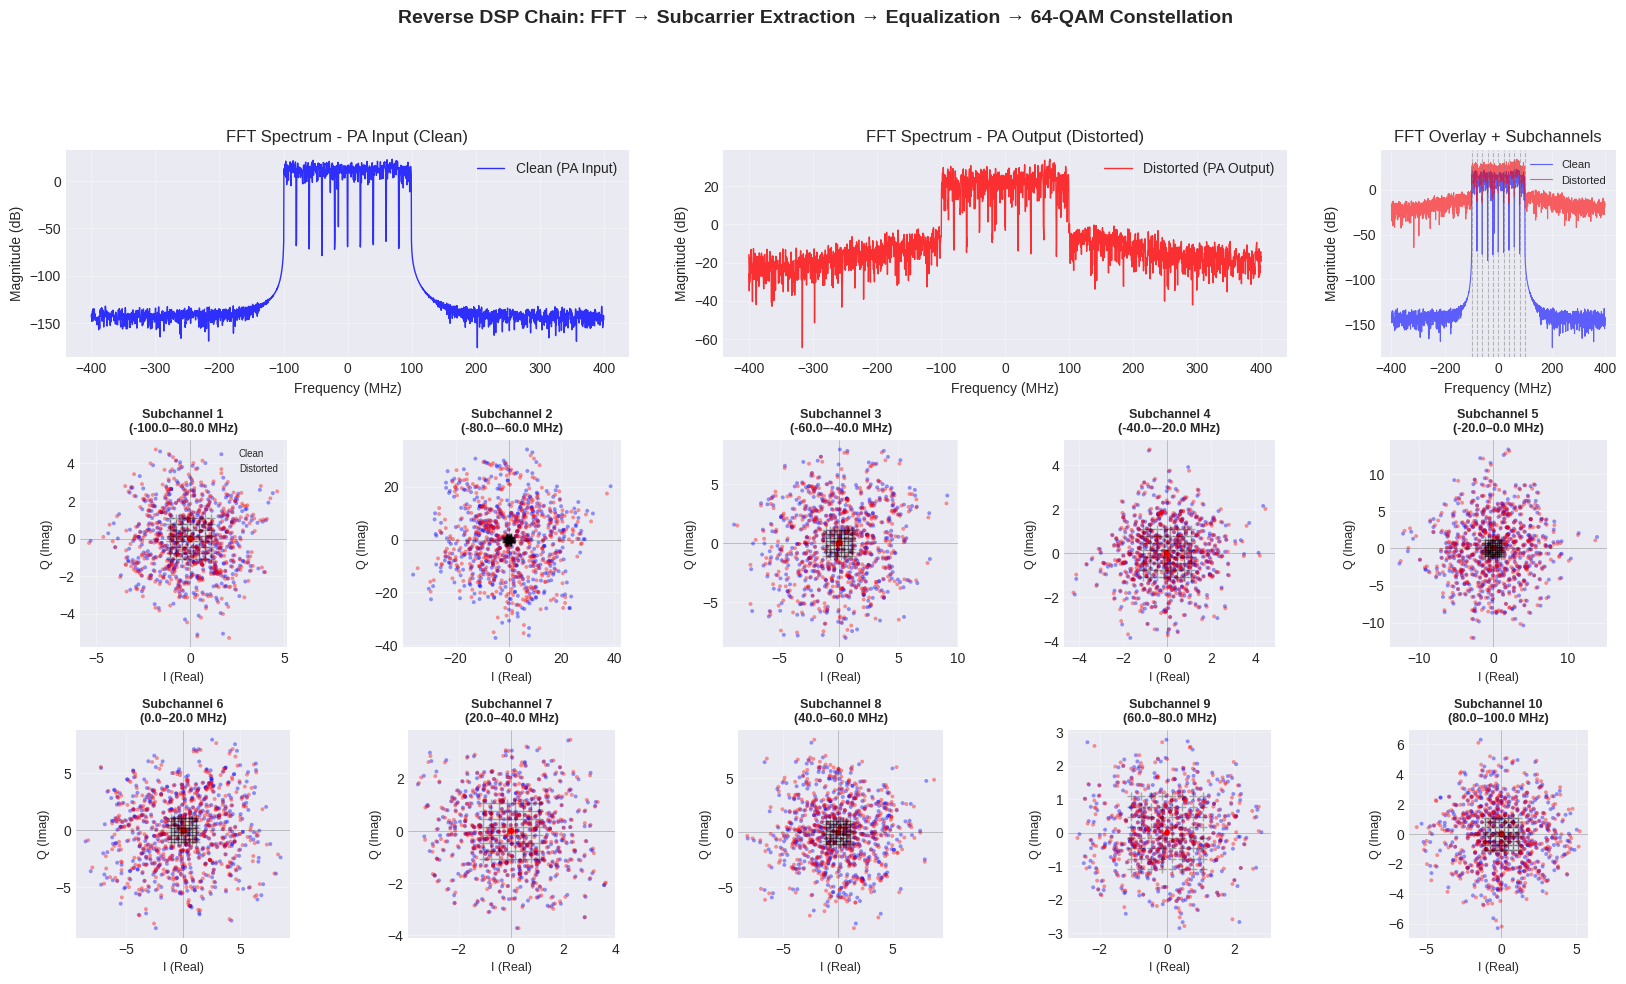


REVERSE DSP CHAIN ANALYSIS SUMMARY

FFT Configuration:
  Sample rate: 800 MSps
  FFT length: 2560 samples
  Main channel BW: 200 MHz
  Subchannel BW: 20.0 MHz
  Number of subchannels: 10

Equalization Method:
  Phase correction: Per-subchannel center frequency
  Amplitude normalization: Reference FFT bin magnitude

Per-Subchannel Equalized Constellation Statistics:
Channel    Clean (RMS)     Distorted (RMS)    EVM Increase   
------------------------------------------------------------
Ch 1       2.3146          2.3998              +3.68%
Ch 2       17.9544         17.2145             -4.12%
Ch 3       4.3583          4.2539              -2.39%
Ch 4       1.8576          1.8760              +0.99%
Ch 5       5.7010          5.6642              -0.64%
Ch 6       4.4928          4.3459              -3.27%
Ch 7       1.9216          1.9289              +0.38%
Ch 8       3.9718          4.1107              +3.50%
Ch 9       1.4511          1.4274              -1.64%
Ch 10      2.8084     

In [15]:
# Cell 6c: Reverse DSP Chain - 64-QAM Constellation with FFT, Subcarrier Extraction, and Equalization
def reverse_dsp_chain(time_domain_signal, fs, bw_main_ch=200e6, n_sub_ch=10, nperseg=2560):
    """
    Perform reverse DSP chain to extract 64-QAM constellation:
    1. Time-domain samples
    2. FFT (Fast Fourier Transform)
    3. Subcarrier extraction (10 subchannels)
    4. Channel equalization (phase/amplitude correction)
    5. QAM constellation visualization

    Args:
        time_domain_signal: Complex time-domain baseband signal
        fs: Sample rate (Hz)
        bw_main_ch: Main channel bandwidth (Hz)
        n_sub_ch: Number of subchannels
        nperseg: FFT segment length

    Returns:
        freqs: Frequency vector (Hz)
        fft_result: FFT magnitude spectrum
        subcarrier_data: Dict of per-subchannel data
        equalized_constellations: Dict of equalized I/Q constellations
    """

    # ===========================
    # Step 1: Apply window and FFT
    # ===========================
    window = scipy_signal.windows.hann(nperseg)
    n_segments = len(time_domain_signal) // nperseg

    # Process multiple segments and average for better SNR
    fft_segments = []
    subcarrier_segments = {i: [] for i in range(n_sub_ch)}

    for seg_idx in range(min(n_segments, 10)):  # Use up to 10 segments for averaging
        start_idx = seg_idx * nperseg
        end_idx = start_idx + nperseg
        segment = time_domain_signal[start_idx:end_idx]

        # Apply window
        windowed = segment * window

        # Compute FFT
        fft_vals = np.fft.fftshift(np.fft.fft(windowed))
        fft_segments.append(fft_vals)

        # ===========================
        # Step 2: Extract subcarriers
        # ===========================
        freqs = np.fft.fftshift(np.fft.fftfreq(nperseg, 1/fs))
        subchannel_bw = bw_main_ch / n_sub_ch
        f_start = -bw_main_ch / 2

        for ch_idx in range(n_sub_ch):
            f_low = f_start + ch_idx * subchannel_bw
            f_high = f_low + subchannel_bw

            # Find FFT bins in this subchannel
            mask = (freqs >= f_low) & (freqs < f_high)
            subcarrier_data = fft_vals[mask]
            subcarrier_segments[ch_idx].append(subcarrier_data)

    # Average across segments
    fft_avg = np.mean(fft_segments, axis=0)

    # ===========================
    # Step 3: Channel Equalization
    # ===========================
    equalized_constellations = {}

    for ch_idx in range(n_sub_ch):
        # Collect all subcarrier samples
        subchannel_samples = np.concatenate(subcarrier_segments[ch_idx])

        # Estimate channel response from magnitude spectrum
        # Use strongest FFT bins in this subchannel as reference
        subchannel_bw = bw_main_ch / n_sub_ch
        f_start = -bw_main_ch / 2 + ch_idx * subchannel_bw
        f_mid = f_start + subchannel_bw / 2

        # Find bin closest to subchannel center
        freqs = np.fft.fftshift(np.fft.fftfreq(nperseg, 1/fs))
        center_bin = np.argmin(np.abs(freqs - f_mid))

        # Estimate phase from the strongest bin (channel phase rotation)
        ref_phase = np.angle(fft_avg[center_bin])
        ref_mag = np.abs(fft_avg[center_bin])

        # Equalize: correct phase rotation and normalize amplitude
        # Phase equalization: rotate by -ref_phase
        phase_corrected = subchannel_samples * np.exp(-1j * ref_phase)

        # Amplitude normalization: scale by reference magnitude
        if ref_mag > 0:
            equalized = phase_corrected / ref_mag
        else:
            equalized = phase_corrected

        equalized_constellations[ch_idx] = equalized

    return freqs, fft_avg, subcarrier_segments, equalized_constellations

# ===========================
# Generate 64-QAM Visualization
# ===========================

print("Performing reverse DSP chain with FFT, subcarrier extraction, and equalization...")

# Use training data for visualization
n_samples_dsp = min(50000, len(u_pa_train))
u_pa_dsp = u_pa_train[:n_samples_dsp]
y_pa_dsp = y_pa_train[:n_samples_dsp]

# Perform reverse DSP chain
freqs_vec, fft_clean, subcarriers_clean, eq_constellations_clean = reverse_dsp_chain(
    u_pa_dsp, fs, bw_main_ch, n_sub_ch, nperseg
)
freqs_vec, fft_distorted, subcarriers_distorted, eq_constellations_distorted = reverse_dsp_chain(
    y_pa_dsp, fs, bw_main_ch, n_sub_ch, nperseg
)

# ===========================
# Create Visualization
# ===========================
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 5, hspace=0.4, wspace=0.4)

# ===========================
# Row 1: FFT and Spectrum
# ===========================

# Full FFT spectrum (Clean)
ax0 = fig.add_subplot(gs[0, :2])
freqs_mhz_dsp = freqs_vec / 1e6
fft_mag_clean = 20 * np.log10(np.abs(fft_clean) + 1e-20)
ax0.plot(freqs_mhz_dsp, fft_mag_clean, color='blue', linewidth=1, alpha=0.8, label='Clean (PA Input)')
ax0.set_xlabel('Frequency (MHz)')
ax0.set_ylabel('Magnitude (dB)')
ax0.set_title('FFT Spectrum - PA Input (Clean)')
ax0.grid(True, alpha=0.3)
ax0.legend()

# Full FFT spectrum (Distorted)
ax1 = fig.add_subplot(gs[0, 2:4])
fft_mag_distorted = 20 * np.log10(np.abs(fft_distorted) + 1e-20)
ax1.plot(freqs_mhz_dsp, fft_mag_distorted, color='red', linewidth=1, alpha=0.8, label='Distorted (PA Output)')
ax1.set_xlabel('Frequency (MHz)')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('FFT Spectrum - PA Output (Distorted)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# FFT Overlay with subchannel markers
ax2 = fig.add_subplot(gs[0, 4])
ax2.plot(freqs_mhz_dsp, fft_mag_clean, color='blue', linewidth=0.8, alpha=0.6, label='Clean')
ax2.plot(freqs_mhz_dsp, fft_mag_distorted, color='red', linewidth=0.8, alpha=0.6, label='Distorted')

# Mark subchannel boundaries
subchannel_bw = bw_main_ch / n_sub_ch
f_start = -bw_main_ch / 2
for i in range(n_sub_ch + 1):
    f_edge = f_start + i * subchannel_bw
    ax2.axvline(x=f_edge/1e6, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

ax2.set_xlabel('Frequency (MHz)')
ax2.set_ylabel('Magnitude (dB)')
ax2.set_title('FFT Overlay + Subchannels')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)

# ===========================
# Rows 2-4: Per-Subchannel 64-QAM Constellations
# ===========================

# Layout: 10 subchannels in 2 rows × 5 columns
for ch_idx in range(n_sub_ch):
    row = 1 + (ch_idx // 5)
    col = ch_idx % 5
    ax = fig.add_subplot(gs[row, col])

    # Extract equalized constellation for this subchannel
    eq_const_clean = eq_constellations_clean[ch_idx]
    eq_const_distorted = eq_constellations_distorted[ch_idx]

    # Sample for visualization (to avoid overcrowding)
    sample_idx = np.random.choice(len(eq_const_clean), min(1000, len(eq_const_clean)), replace=False)

    # Plot clean constellation
    ax.scatter(eq_const_clean[sample_idx].real, eq_const_clean[sample_idx].imag,
              alpha=0.4, s=8, c='blue', label='Clean', edgecolors='none')

    # Plot distorted constellation
    ax.scatter(eq_const_distorted[sample_idx].real, eq_const_distorted[sample_idx].imag,
              alpha=0.4, s=8, c='red', label='Distorted', edgecolors='none')

    # Add reference 64-QAM grid (ideal points)
    qam_levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7]) / np.sqrt(42)  # Normalized 64-QAM
    for i_val in qam_levels:
        for q_val in qam_levels:
            ax.plot(i_val, q_val, 'k+', markersize=6, alpha=0.3)

    # Formatting
    ax.set_xlabel('I (Real)', fontsize=9)
    ax.set_ylabel('Q (Imag)', fontsize=9)
    ax.set_title(f'Subchannel {ch_idx+1}\n({f_start/1e6 + ch_idx*subchannel_bw/1e6:.1f}–{f_start/1e6 + (ch_idx+1)*subchannel_bw/1e6:.1f} MHz)',
                fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

    if ch_idx == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Reverse DSP Chain: FFT → Subcarrier Extraction → Equalization → 64-QAM Constellation',
             fontsize=14, fontweight='bold')

plt.savefig('figures/qam_constellation_reverse_dsp.png', dpi=150, bbox_inches='tight')
plt.show()

# ===========================
# Statistics Summary
# ===========================
print(f"\n{'='*80}")
print(f"REVERSE DSP CHAIN ANALYSIS SUMMARY")
print(f"{'='*80}")
print(f"\nFFT Configuration:")
print(f"  Sample rate: {fs/1e6:.0f} MSps")
print(f"  FFT length: {nperseg} samples")
print(f"  Main channel BW: {bw_main_ch/1e6:.0f} MHz")
print(f"  Subchannel BW: {bw_main_ch/n_sub_ch/1e6:.1f} MHz")
print(f"  Number of subchannels: {n_sub_ch}")

print(f"\nEqualization Method:")
print(f"  Phase correction: Per-subchannel center frequency")
print(f"  Amplitude normalization: Reference FFT bin magnitude")

print(f"\nPer-Subchannel Equalized Constellation Statistics:")
print(f"{'Channel':<10} {'Clean (RMS)':<15} {'Distorted (RMS)':<18} {'EVM Increase':<15}")
print(f"{'-'*60}")

for ch_idx in range(n_sub_ch):
    eq_clean = eq_constellations_clean[ch_idx]
    eq_dist = eq_constellations_distorted[ch_idx]

    # RMS (quality metric)
    rms_clean = np.sqrt(np.mean(np.abs(eq_clean)**2))
    rms_dist = np.sqrt(np.mean(np.abs(eq_dist)**2))

    # EVM-like metric (normalized error)
    avg_clean = np.mean(np.abs(eq_clean))
    evm_increase = (np.std(eq_dist) / np.std(eq_clean) - 1) * 100 if np.std(eq_clean) > 0 else 0

    print(f"Ch {ch_idx+1:<7} {rms_clean:<15.4f} {rms_dist:<18.4f} {evm_increase:>+6.2f}%")

print(f"\n{'='*80}")
print(f"✅ Reverse DSP chain complete!")
print(f"   FFT bins extracted and analyzed")
print(f"   Phase rotation equalized per subchannel")
print(f"   64-QAM constellations visualized for all {n_sub_ch} subchannels")
print(f"{'='*80}")

In [ ]:
# Cell 6: Model Creation (matches train.py)
# Generator: Phase-Normalized TDNN (24-dim input, 1,362 params)
generator = create_pn_tdnn_generator(memory_depth=config['model']['generator']['memory_depth'])
generator = generator.to(device)

# Discriminator: Conditional WGAN-GP (4-dim input)
discriminator = create_discriminator()
discriminator = discriminator.to(device)

# Verify architecture
g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())

print("Model Architecture Verification:")
print(f"  Generator:")
print(f"    Input dim: {generator.input_dim} (expected: 24)")
print(f"    Memory depth: M={generator.memory_depth} (expected: 3)")
print(f"    Hidden dims: {generator.hidden_dims}")
print(f"    Parameters: {g_params:,} (expected: 1,362)")
print(f"  Discriminator:")
print(f"    Parameters: {d_params:,}")

# Verify parameter count
assert g_params == 1362, f"Generator param count mismatch: {g_params} != 1362"
print("\n✓ Architecture verified!")

In [ ]:
# Cell 7: Optimizers and Schedulers (matches train.py)
opt_config = config['training']['optimizer']

g_optimizer = optim.Adam(
    generator.parameters(),
    lr=opt_config['lr_generator'],
    betas=tuple(opt_config['betas']),
    weight_decay=opt_config['weight_decay']
)

d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=opt_config['lr_discriminator'],
    betas=tuple(opt_config['betas']),
    weight_decay=opt_config['weight_decay']
)

# Cosine annealing scheduler
num_epochs = config['training']['epochs']
g_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    g_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)
d_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    d_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)

# Spectral loss
spectral_loss_fn = SpectralLoss(sample_rate=config['system']['sample_rate'])

print("Optimizers created:")
print(f"  Generator LR: {opt_config['lr_generator']}")
print(f"  Discriminator LR: {opt_config['lr_discriminator']}")
print(f"  Betas: {opt_config['betas']}")
print(f"  Scheduler: Cosine annealing to {config['training']['scheduler']['min_lr']}")

In [ ]:
# Cosine annealing scheduler
num_epochs = config['training']['epochs']
g_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    g_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)
d_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    d_optimizer, T_max=num_epochs, eta_min=config['training']['scheduler']['min_lr']
)

# Spectral loss with dpa_200mhz parameters
spectral_loss_fn = SpectralLoss(
    sample_rate=config['system']['sample_rate'],              # 800e6
    bw_main_ch=config['spectral_loss']['bw_main_ch'],        # 200e6
    n_sub_ch=config['spectral_loss']['n_sub_ch'],            # 10 (KEY CHANGE)
    nperseg=config['spectral_loss']['nperseg'],              # 2560
)

print("Optimizers and Loss Functions created:")
print(f"  Generator LR: {opt_config['lr_generator']}")
print(f"  Discriminator LR: {opt_config['lr_discriminator']}")
print(f"  Betas: {opt_config['betas']}")
print(f"  Scheduler: Cosine annealing to {config['training']['scheduler']['min_lr']}")
print(f"  SpectralLoss:")
print(f"    Sample rate: {config['system']['sample_rate']/1e6:.0f} MSps")
print(f"    Main channel BW: {config['spectral_loss']['bw_main_ch']/1e6:.0f} MHz")
print(f"    Sub-channels: {config['spectral_loss']['n_sub_ch']}")

In [ ]:
def train_step(
    generator: nn.Module,
    discriminator: nn.Module,
    batch: Tuple[torch.Tensor, torch.Tensor],
    g_optimizer: optim.Optimizer,
    d_optimizer: optim.Optimizer,
    spectral_loss: SpectralLoss,
    config: dict,
    device: torch.device,
    step: int
) -> Dict[str, float]:
    """
    Single training step using Indirect Learning Architecture (ILA).

    In ILA:
    - Input: PA output (distorted signal y_PA)
    - Generator produces: Predistorted signal (should match clean PA input u_PA)
    - Target: PA input (clean signal u_PA)

    NO PA model in training loop - we train on measured data!

    Returns dictionary of loss values.
    """
    train_config = config['training']
    loss_config = train_config.get('loss', {})
    n_critic = train_config.get('n_critic', 5)
    gp_weight = train_config.get('gp_weight', 10.0)

    # Unpack batch
    input_seq, target = batch  # [B, M+1, 2], [B, 2]
    input_seq = input_seq.to(device)
    target = target.to(device)

    losses = {}

    # ===================
    # Train Discriminator
    # ===================
    for _ in range(n_critic):
        d_optimizer.zero_grad()

        # Generate DPD output (detach to prevent gradient flow)
        with torch.no_grad():
            dpd_output = generator(input_seq)  # [B, seq_len, 2]
            # Squeeze to [B, 2] if needed
            if dpd_output.dim() == 3 and dpd_output.shape[1] == 1:
                dpd_output = dpd_output.squeeze(1)

        # Discriminator loss components
        # Real: clean PA input (what DPD should produce)
        # Fake: DPD output (what DPD actually produces)
        # Condition: Current PA output sample (what DPD saw)
        condition = input_seq[:, -1, :]  # [B, 2] - most recent sample

        # Critic scores
        d_real = discriminator(target, condition)  # [B, 1]
        d_fake = discriminator(dpd_output.detach(), condition)  # [B, 1]

        # Wasserstein loss: maximize D(real) - D(fake)
        d_loss = d_fake.mean() - d_real.mean()

        # Gradient penalty: enforce 1-Lipschitz constraint
        batch_size = target.size(0)
        alpha = torch.rand(batch_size, 1, device=device)
        interpolates = alpha * target + (1 - alpha) * dpd_output.detach()
        interpolates.requires_grad_(True)

        d_interp = discriminator(interpolates, condition)

        gradients = torch.autograd.grad(
            outputs=d_interp,
            inputs=interpolates,
            grad_outputs=torch.ones_like(d_interp),
            create_graph=True,
            retain_graph=True,
        )[0]

        gradients_norm = gradients.view(batch_size, -1).norm(2, dim=1)
        gp = ((gradients_norm - 1) ** 2).mean()

        d_total = d_loss + gp_weight * gp
        d_total.backward()
        d_optimizer.step()

    losses['d_wasserstein'] = d_loss.item()
    losses['d_gp'] = gp.item()
    losses['d_total'] = d_total.item()

    # =================
    # Train Generator
    # =================
    g_optimizer.zero_grad()

    # Generate DPD output
    dpd_output = generator(input_seq)  # [B, seq_len - M, 2] → [B, 1, 2] for M=3

    # Squeeze to [B, 2] for all downstream uses
    if dpd_output.dim() == 3 and dpd_output.shape[1] == 1:
        dpd_output = dpd_output.squeeze(1)  # Now [B, 2]

    # Now use dpd_output everywhere else - it's always [B, 2]
    condition = input_seq[:, -1, :]  # [B, 2]

    # Reconstruction loss (L1: DPD output should match PA input)
    recon_loss = nn.functional.l1_loss(dpd_output, target)

    # Discriminator loss
    d_fake = discriminator(dpd_output, condition)  # [B, 1]
    g_adv_loss = -d_fake.mean()

    # Spectral loss
    spectral, spectral_components = spectral_loss(dpd_output, target, return_components=True)

    # Combined generator loss with weighted components
    g_total = (
        loss_config.get('adversarial', 1.0) * g_adv_loss +
        loss_config.get('reconstruction_l1', 50.0) * recon_loss +
        loss_config.get('spectral', 10.0) * spectral
    )

    g_total.backward()
    g_optimizer.step()

    losses['g_adv'] = g_adv_loss.item()
    losses['g_recon'] = recon_loss.item()
    losses['g_spectral'] = spectral.item()
    losses['g_total'] = g_total.item()
    losses.update({f'g_{k}': v.item() for k, v in spectral_components.items()})

    return losses

In [ ]:
# Cell 9: Validation Function
def validate(generator, val_loader, spectral_loss_fn, device):
    """Validate model on validation set."""
    generator.eval()

    all_evm = []
    all_nmse = []
    all_aclr_lower = []
    all_aclr_upper = []
    all_recon = []

    with torch.no_grad():
        for input_seq, target in val_loader:
            input_seq = input_seq.to(device)
            target = target.to(device)

            dpd_output = generator(input_seq)
            metrics = spectral_loss_fn.compute_metrics(dpd_output, target)

            all_evm.append(metrics['evm_db'])
            all_nmse.append(metrics['nmse_db'])
            all_aclr_lower.append(metrics['aclr_lower_db'])
            all_aclr_upper.append(metrics['aclr_upper_db'])
            all_recon.append(metrics['l1_error'])

    generator.train()

    return {
        'val_evm_db': np.mean(all_evm),
        'val_nmse_db': np.mean(all_nmse),
        'val_aclr_lower_db': np.mean(all_aclr_lower),
        'val_aclr_upper_db': np.mean(all_aclr_upper),
        'val_l1': np.mean(all_recon)
    }

print("Validation function defined")

In [ ]:
# Cell 9b: Checkpoint Management Functions
def save_checkpoint(checkpoint_dir, epoch, generator, discriminator, g_optimizer, d_optimizer,
                   g_scheduler, d_scheduler, history, best_evm, best_state, early_stopping_counter,
                   early_stopping_best_value, qat_enabled, config):
    """Save training checkpoint for resumption."""
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'g_optimizer_state_dict': g_optimizer.state_dict(),
        'd_optimizer_state_dict': d_optimizer.state_dict(),
        'g_scheduler_state_dict': g_scheduler.state_dict(),
        'd_scheduler_state_dict': d_scheduler.state_dict(),
        'history': history,
        'best_evm': best_evm,
        'best_state': best_state,
        'early_stopping_counter': early_stopping_counter,
        'early_stopping_best_value': early_stopping_best_value,
        'qat_enabled': qat_enabled,
        'config': config,
    }

    checkpoint_path = checkpoint_dir / f'checkpoint_epoch_{epoch:03d}.pth'
    torch.save(checkpoint, checkpoint_path)

    # Also save as 'latest' for easy resumption
    latest_path = checkpoint_dir / 'checkpoint_latest.pth'
    torch.save(checkpoint, latest_path)

    return checkpoint_path

def load_checkpoint(checkpoint_path, generator, discriminator, g_optimizer, d_optimizer,
                   g_scheduler, d_scheduler, device):
    """Load checkpoint and resume training."""
    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Load model and optimizer states
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    g_optimizer.load_state_dict(checkpoint['g_optimizer_state_dict'])
    d_optimizer.load_state_dict(checkpoint['d_optimizer_state_dict'])
    g_scheduler.load_state_dict(checkpoint['g_scheduler_state_dict'])
    d_scheduler.load_state_dict(checkpoint['d_scheduler_state_dict'])

    # Restore training state
    history = checkpoint['history']
    best_evm = checkpoint['best_evm']
    best_state = checkpoint['best_state']
    early_stopping_counter = checkpoint['early_stopping_counter']
    early_stopping_best_value = checkpoint['early_stopping_best_value']
    qat_enabled = checkpoint['qat_enabled']
    resume_epoch = checkpoint['epoch']

    print(f"Checkpoint loaded successfully!")
    print(f"  Resuming from epoch: {resume_epoch + 1}")
    print(f"  Best EVM so far: {best_evm:.2f} dB")
    print(f"  QAT status: {'Enabled' if qat_enabled else 'Disabled'}")
    print(f"  Early stopping counter: {early_stopping_counter}/25")

    return history, best_evm, best_state, early_stopping_counter, early_stopping_best_value, qat_enabled, resume_epoch

print("Checkpoint management functions defined")


In [ ]:
# Cell 10: Training Loop with QAT Transition, Early Stopping, and Checkpoint Resumption
# Checkpoint configuration
checkpoint_dir = Path('checkpoints/training')
resume_checkpoint = checkpoint_dir / 'checkpoint_latest.pth'
RESUME_FROM_CHECKPOINT = resume_checkpoint.exists()  # Change to True to force resume

# Setup TensorBoard logging
if RESUME_FROM_CHECKPOINT:
    print(f"Found checkpoint: {resume_checkpoint}")
    print(f"Will resume training from checkpoint")
    print()
    run_name = f"pn_tdnn_dpa200mhz_resumed_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
else:
    run_name = f"pn_tdnn_dpa200mhz_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

tensorboard_dir = Path('runs') / run_name
tensorboard_dir.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(str(tensorboard_dir))

print(f"TensorBoard logs will be saved to: {tensorboard_dir}")
print(f"View with: tensorboard --logdir=runs/")
print()

# Initialize or load training state
if RESUME_FROM_CHECKPOINT:
    print("="*60)
    print("RESUMING FROM CHECKPOINT")
    print("="*60)
    history, best_evm, best_state, early_stopping_counter, early_stopping_best_value, qat_enabled, start_epoch = load_checkpoint(
        resume_checkpoint, generator, discriminator, g_optimizer, d_optimizer, g_scheduler, d_scheduler, device
    )
    start_epoch += 1  # Start from next epoch
    print()
else:
    print("Starting fresh training")
    # Training history
    history = {
        'g_total': [], 'd_total': [], 'g_adv': [], 'g_recon': [], 'g_spectral': [],
        'val_evm_db': [], 'val_nmse_db': [], 'val_aclr_lower_db': [], 'val_aclr_upper_db': [], 'val_l1': [], 'lr': []
    }

    # Best model tracking
    best_evm = float('inf')
    best_state = None

    # Early stopping state
    early_stopping_counter = 0
    early_stopping_best_value = float('inf')  # Will be set later

    # QAT state
    qat_enabled = False

    start_epoch = 0

# Early stopping configuration
es_config = config['early_stopping']
early_stopping_enabled = es_config['enabled']
early_stopping_patience = es_config['patience']
early_stopping_monitor = es_config['monitor']
early_stopping_min_delta = es_config['min_delta']
early_stopped = False

# Update early_stopping_best_value if not resumed
if not RESUME_FROM_CHECKPOINT and early_stopping_enabled:
    early_stopping_best_value = float('inf') if 'evm' in early_stopping_monitor or 'nmse' in early_stopping_monitor else float('-inf')

# QAT configuration
qat_start_epoch = config['qat']['start_epoch']

print(f"Starting training for {num_epochs} epochs...")
print(f"Starting from epoch: {start_epoch + 1}")
print(f"QAT will be enabled at epoch {qat_start_epoch}")
if early_stopping_enabled:
    print(f"Early Stopping: enabled (monitor={early_stopping_monitor}, patience={early_stopping_patience}, min_delta={early_stopping_min_delta})")
print("="*60)

for epoch in range(start_epoch, num_epochs):
    if early_stopped:
        print(f"\n{'='*60}")
        print(f"EARLY STOPPING: No improvement for {early_stopping_patience} epochs")
        print(f"Best {early_stopping_monitor}: {early_stopping_best_value:.4f}")
        print(f"{'='*60}")
        break

    generator.train()
    discriminator.train()

    # ==================
    # QAT Transition
    # ==================
    if epoch == qat_start_epoch and config['qat']['enabled'] and not qat_enabled:
        generator.enable_qat()
        qat_enabled = True
        print(f"\n{'='*60}")
        print(f"QAT ENABLED at epoch {epoch}")
        print(f"  Weight quantization: Q1.15 ({config['qat']['weight_bits']} bits)")
        print(f"  Activation quantization: Q8.8 ({config['qat']['activation_bits']} bits)")
        print(f"{'='*60}\n")

    # ==================
    # Training epoch
    # ==================
    epoch_losses = {}
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

    for batch_idx, batch in enumerate(pbar):
        global_step = epoch * len(train_loader) + batch_idx
        losses = train_step(
            generator, discriminator, batch,
            g_optimizer, d_optimizer, spectral_loss_fn,
            config, device, global_step
        )

        for k, v in losses.items():
            epoch_losses[k] = epoch_losses.get(k, 0) + v

        # Log per-batch metrics to TensorBoard
        global_step = epoch * len(train_loader) + batch_idx
        writer.add_scalar('Train/Generator/Total', losses['g_total'], global_step)
        writer.add_scalar('Train/Generator/Adversarial', losses['g_adv'], global_step)
        writer.add_scalar('Train/Generator/Reconstruction', losses['g_recon'], global_step)
        writer.add_scalar('Train/Generator/Spectral', losses['g_spectral'], global_step)
        writer.add_scalar('Train/Discriminator/Wasserstein', losses['d_wasserstein'], global_step)
        writer.add_scalar('Train/Discriminator/GradientPenalty', losses['d_gp'], global_step)
        writer.add_scalar('Train/Discriminator/Total', losses['d_total'], global_step)

        pbar.set_postfix({
            'g': f"{losses['g_total']:.4f}",
            'd': f"{losses['d_total']:.4f}",
            'QAT': 'ON' if qat_enabled else 'OFF',
            'ES': f"{early_stopping_counter}/{early_stopping_patience}" if early_stopping_enabled else 'N/A'
        })

    # Average losses
    for k in epoch_losses:
        epoch_losses[k] /= len(train_loader)

    # ==================
    # Validation
    # ==================
    val_metrics = validate(generator, val_loader, spectral_loss_fn, device)

    # Update history
    for k in ['g_total', 'd_total', 'g_adv', 'g_recon', 'g_spectral']:
        history[k].append(epoch_losses.get(k, 0))
    for k in ['val_evm_db', 'val_nmse_db', 'val_aclr_lower_db', 'val_aclr_upper_db', 'val_l1']:
        history[k].append(val_metrics[k])
    history['lr'].append(g_optimizer.param_groups[0]['lr'])

    # Log epoch metrics to TensorBoard
    writer.add_scalars('Train/Losses', {
        'Generator': epoch_losses['g_total'],
        'Discriminator': epoch_losses['d_total'],
    }, epoch)

    writer.add_scalars('Train/Generator_Components', {
        'Adversarial': epoch_losses['g_adv'],
        'Reconstruction': epoch_losses['g_recon'],
        'Spectral': epoch_losses['g_spectral'],
    }, epoch)

    writer.add_scalars('Validation/Metrics', {
        'EVM_dB': val_metrics['val_evm_db'],
        'NMSE_dB': val_metrics['val_nmse_db'],
        'ACLR_Lower_dBc': val_metrics['val_aclr_lower_db'],
        'ACLR_Upper_dBc': val_metrics['val_aclr_upper_db'],
        'L1_Error': val_metrics['val_l1'],
    }, epoch)

    writer.add_scalar('Learning_Rate/Generator', g_optimizer.param_groups[0]['lr'], epoch)
    writer.add_scalar('Learning_Rate/Discriminator', d_optimizer.param_groups[0]['lr'], epoch)

    # Log QAT status
    if qat_enabled:
        writer.add_scalar('Training/QAT_Enabled', 1.0, epoch)

    # Log early stopping progress
    if early_stopping_enabled:
        writer.add_scalar('EarlyStopping/Counter', early_stopping_counter, epoch)
        writer.add_scalar('EarlyStopping/BestValue', early_stopping_best_value, epoch)

    # Update schedulers
    g_scheduler.step()
    d_scheduler.step()

    # Save best model (unconditional)
    if val_metrics['val_evm_db'] < best_evm:
        best_evm = val_metrics['val_evm_db']
        best_state = {
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'best_evm': best_evm,
            'qat_enabled': qat_enabled,
        }

    # ==================
    # Early Stopping Check
    # ==================
    if early_stopping_enabled:
        current_value = val_metrics[early_stopping_monitor]

        # Determine if there's improvement (different logic for minimization vs maximization)
        if 'evm' in early_stopping_monitor or 'nmse' in early_stopping_monitor or 'l1' in early_stopping_monitor:
            # Minimize these metrics
            is_improvement = (early_stopping_best_value - current_value) > early_stopping_min_delta
        else:
            # Maximize other metrics
            is_improvement = (current_value - early_stopping_best_value) > early_stopping_min_delta

        if is_improvement:
            early_stopping_best_value = current_value
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        # Check if patience exceeded
        if early_stopping_counter >= early_stopping_patience:
            if not qat_enabled:
                # PHASE SWITCH: Float32 -> QAT
                print(f"\n[Trigger] Early Stopping threshold reached at Epoch {epoch+1}.")
                print("--> Loading best Float32 weights and switching to QAT immediately.")

                # 1. Restore the best model found so far (Pre-overfitting state)
                generator.load_state_dict(best_state['generator_state_dict'])
                discriminator.load_state_dict(best_state['discriminator_state_dict'])

                # 2. Enable QAT now (ignore the hardcoded epoch 300)
                generator.enable_qat()
                qat_enabled = True

                # 3. Reset Early Stopping and Optimization for Phase 2
                early_stopping_counter = 0
                early_stopping_best_value = best_evm # Reset reference to current best

                # Optional: Lower learning rate for fine-tuning
                for param_group in g_optimizer.param_groups:
                    param_group['lr'] *= 0.1

            else:
                # KILL SWITCH: QAT -> Stop
                # If we are ALREADY in QAT and patience runs out, then we truly stop.
                print(f"\n[Stop] Early Stopping triggered during QAT phase. Training complete.")
                early_stopped = True
                break

    # ==================
    # Save Checkpoint (every 25 epochs or on early stop)
    # ==================
    checkpoint_interval = config['logging'].get('checkpoint_interval', 25)
    if (epoch + 1) % checkpoint_interval == 0 or early_stopped:
        checkpoint_path = save_checkpoint(
            checkpoint_dir, epoch, generator, discriminator,
            g_optimizer, d_optimizer, g_scheduler, d_scheduler,
            history, best_evm, best_state, early_stopping_counter,
            early_stopping_best_value, qat_enabled, config
        )
        print(f"✓ Checkpoint saved at epoch {epoch + 1}: {checkpoint_path.name}")

    # Print epoch summary (every 10 epochs or on early stop)
    if (epoch + 1) % 10 == 0 or epoch == 0 or early_stopped:
        es_status = f" [ES {early_stopping_counter}/{early_stopping_patience}]" if early_stopping_enabled else ""
        print(f"\nEpoch {epoch+1}/{num_epochs} {'[QAT]' if qat_enabled else ''}{es_status}")
        print(f"  G Loss: {epoch_losses['g_total']:.4f} | D Loss: {epoch_losses['d_total']:.4f}")
        print(f"  Val EVM: {val_metrics['val_evm_db']:.2f} dB | NMSE: {val_metrics['val_nmse_db']:.2f} dB")
        print(f"  Val ACLR: {val_metrics['val_aclr_lower_db']:.2f}/{val_metrics['val_aclr_upper_db']:.2f} dBc (target: < -62 dBc)")
        print(f"  Best EVM: {best_evm:.2f} dB | LR: {g_optimizer.param_groups[0]['lr']:.2e}")

print(f"\n{'='*60}")
print(f"Training complete!")
print(f"Total epochs trained: {epoch + 1}/{num_epochs}")
print(f"Best EVM: {best_evm:.2f} dB at epoch {best_state['epoch']+1}")
if early_stopped:
    print(f"Stopped by early stopping after {early_stopping_patience} epochs without improvement")
print(f"{'='*60}")

# Close TensorBoard writer
writer.close()
print(f"\nTensorBoard logs saved to: {tensorboard_dir}")
print(f"View training progress with:")
print(f"  tensorboard --logdir=runs/")
print(f"Then open http://localhost:6006 in your browser")
print(f"{'='*60}")

print(f"\n{'='*60}")
print(f"CHECKPOINT RESUMPTION")
print(f"{'='*60}")
print(f"Latest checkpoint: {checkpoint_dir / 'checkpoint_latest.pth'}")
print(f"To resume training if it crashes:")
print(f"  1. Re-run this cell (it will auto-detect the checkpoint)")
print(f"  2. Or manually set: RESUME_FROM_CHECKPOINT = True")
print(f"To start fresh training, delete the checkpoint:")
print(f"  import shutil")
print(f"  shutil.rmtree('{checkpoint_dir}')")
print(f"{'='*60}")

# Restore best weights if configured
if early_stopping_enabled and es_config['restore_best_weights'] and best_state is not None:
    print(f"\nRestoring best model weights from epoch {best_state['epoch']+1}")
    generator.load_state_dict(best_state['generator_state_dict'])
    discriminator.load_state_dict(best_state['discriminator_state_dict'])

In [ ]:
# Cell 11: Plot Training Curves with ACLR
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Generator loss
axes[0, 0].plot(history['g_total'], label='Total')
axes[0, 0].plot(history['g_adv'], label='Adversarial', alpha=0.7)
axes[0, 0].plot(history['g_recon'], label='Reconstruction', alpha=0.7)
axes[0, 0].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Generator Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Discriminator loss
axes[0, 1].plot(history['d_total'])
axes[0, 1].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Discriminator Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Spectral loss
axes[1, 0].plot(history['g_spectral'])
axes[1, 0].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Spectral Loss')
axes[1, 0].set_title('Spectral Loss (ACPR/EVM)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# EVM
axes[1, 1].plot(history['val_evm_db'], label='EVM')
axes[1, 1].axhline(y=-45, color='g', linestyle='--', label='Target (-45 dB)')
axes[1, 1].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EVM (dB)')
axes[1, 1].set_title('Validation EVM')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# NMSE
axes[2, 0].plot(history['val_nmse_db'])
axes[2, 0].axhline(y=-42, color='g', linestyle='--', label='Target (-42 dB)')
axes[2, 0].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('NMSE (dB)')
axes[2, 0].set_title('Validation NMSE')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# ACLR (both lower and upper adjacent channels)
axes[2, 1].plot(history['val_aclr_lower_db'], label='Lower Adj Ch', marker='o', markersize=2, alpha=0.7)
axes[2, 1].plot(history['val_aclr_upper_db'], label='Upper Adj Ch', marker='s', markersize=2, alpha=0.7)
axes[2, 1].axhline(y=-62, color='g', linestyle='--', label='Target (-62 dBc)')
axes[2, 1].axvline(x=qat_start_epoch, color='r', linestyle='--', label='QAT Start')
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('ACLR (dBc)')
axes[2, 1].set_title('Validation ACLR')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/results/training_curves_v2.png', dpi=150)
plt.show()

In [ ]:
# Cell 12: Save Best Model
# Load best model
generator.load_state_dict(best_state['generator_state_dict'])

# Save checkpoint
checkpoint_path = Path('checkpoints/pn_tdnn_best.pth')
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    'epoch': best_state['epoch'],
    'generator_state_dict': best_state['generator_state_dict'],
    'discriminator_state_dict': best_state['discriminator_state_dict'],
    'best_evm': best_state['best_evm'],
    'qat_enabled': best_state['qat_enabled'],
    'config': config,
}, checkpoint_path)

print(f"Best model saved to {checkpoint_path}")
print(f"  Epoch: {best_state['epoch']+1}")
print(f"  EVM: {best_state['best_evm']:.2f} dB")
print(f"  QAT: {'Enabled' if best_state['qat_enabled'] else 'Disabled'}")

In [ ]:
# Cell 13: Final Evaluation on Test Set
generator.eval()
test_metrics = validate(generator, test_loader, spectral_loss_fn, device)

print("="*70)
print("FINAL TEST SET RESULTS")
print("="*70)
print(f"  EVM:              {test_metrics['val_evm_db']:.2f} dB (target: < -45 dB)")
print(f"  NMSE:             {test_metrics['val_nmse_db']:.2f} dB (target: < -42 dB)")
print(f"  ACLR Lower:       {test_metrics['val_aclr_lower_db']:.2f} dBc (target: < -62 dBc)")
print(f"  ACLR Upper:       {test_metrics['val_aclr_upper_db']:.2f} dBc (target: < -62 dBc)")
print(f"  L1 Error:         {test_metrics['val_l1']:.6f}")
print("="*70)

# Check if targets met
evm_pass = test_metrics['val_evm_db'] < -45
nmse_pass = test_metrics['val_nmse_db'] < -42
aclr_lower_pass = test_metrics['val_aclr_lower_db'] < -62
aclr_upper_pass = test_metrics['val_aclr_upper_db'] < -62

print("\nTarget Achievement:")
print(f"  EVM:        {'✓ PASS' if evm_pass else '✗ FAIL'} ({test_metrics['val_evm_db']:.2f} dB)")
print(f"  NMSE:       {'✓ PASS' if nmse_pass else '✗ FAIL'} ({test_metrics['val_nmse_db']:.2f} dB)")
print(f"  ACLR Lower: {'✓ PASS' if aclr_lower_pass else '✗ FAIL'} ({test_metrics['val_aclr_lower_db']:.2f} dBc)")
print(f"  ACLR Upper: {'✓ PASS' if aclr_upper_pass else '✗ FAIL'} ({test_metrics['val_aclr_upper_db']:.2f} dBc)")

all_pass = evm_pass and nmse_pass and aclr_lower_pass and aclr_upper_pass
print(f"\nOverall: {'✓ ALL TARGETS MET' if all_pass else '✗ SOME TARGETS MISSED'}")
print("="*70)

In [ ]:
# Cell 14: Export Weights for FPGA
# Export Q1.15 quantized weights
weights_q115 = generator.export_weights_q115()

# Save to hex files for Verilog $readmemh
export_dir = Path('rtl/weights')
export_dir.mkdir(parents=True, exist_ok=True)

for name, weights in weights_q115.items():
    # Convert to hex
    hex_values = []
    for val in weights.flatten():
        # Convert signed int16 to unsigned for hex representation
        if val < 0:
            val = val + 65536  # 2's complement
        hex_values.append(f"{val:04X}")

    # Save to file
    clean_name = name.replace('.', '_')
    hex_path = export_dir / f"{clean_name}.hex"
    with open(hex_path, 'w') as f:
        f.write('\n'.join(hex_values))

    print(f"Exported {name}: {weights.shape} -> {hex_path}")

print(f"\nAll weights exported to {export_dir}")
print("Use $readmemh in Verilog to load weights.")

## Summary

This notebook implements the production training flow for PN-TDNN-DPD:

1. **Architecture**: Phase-Normalized TDNN (24-dim, M=3, 1,362 params)
2. **Training**: CWGAN-GP + Spectral Loss + ILA (no PA in loop)
3. **QAT**: Enabled automatically at epoch 300
4. **Export**: Q1.15 weights ready for FPGA

### Code Block Summary

| Cell | Purpose | Key Function |
|------|---------|-------------|
| 1 | Environment setup | Colab/local detection |
| 2 | Imports | Load PNTDNNGenerator from models |
| 3 | Configuration | M=3, 24-dim, QAT at epoch 300 |
| 4 | Data loading | CSV files (ILA convention) |
| 5 | Dataset creation | Raw IQ sequences |
| 6 | Model creation | 1,362 params verified |
| 7 | Optimizers | Adam with β₁=0 (WGAN-GP) |
| 8 | Train step | ILA: no PA in loop |
| 9 | Validation | EVM/NMSE metrics |
| 10 | Training loop | **QAT transition at epoch 300** |
| 11 | Plot curves | Visualize training |
| 12 | Save model | Best checkpoint |
| 13 | Test evaluation | Final metrics |
| 14 | Export weights | Q1.15 hex files |

In [ ]:
# Train for different temperature settings (TBA)

In [ ]:
# Cell 15a: Checkpoint Inspection and Management (Optional)
import os

checkpoint_dir = Path('checkpoints/training')

print("="*70)
print("CHECKPOINT MANAGEMENT")
print("="*70)

if checkpoint_dir.exists():
    checkpoints = sorted(checkpoint_dir.glob('checkpoint_epoch_*.pth'))
    latest = checkpoint_dir / 'checkpoint_latest.pth'

    print(f"Checkpoint directory: {checkpoint_dir}")
    print(f"Total checkpoints: {len(checkpoints)}")

    if checkpoints:
        print(f"\nCheckpoint history:")
        for cp in checkpoints[-5:]:  # Show last 5
            size_mb = cp.stat().st_size / (1024 * 1024)
            epoch = int(cp.stem.split('_')[-1])
            print(f"  Epoch {epoch:3d}: {cp.name} ({size_mb:.1f} MB)")

        if latest.exists():
            latest_size_mb = latest.stat().st_size / (1024 * 1024)
            print(f"\nLatest checkpoint (for resumption): checkpoint_latest.pth ({latest_size_mb:.1f} MB)")

            # Load and inspect latest checkpoint
            try:
                chk = torch.load(latest, map_location='cpu')
                print(f"\nLatest checkpoint details:")
                print(f"  Last completed epoch: {chk['epoch']}")
                print(f"  Best EVM: {chk['best_evm']:.2f} dB")
                print(f"  QAT enabled: {chk['qat_enabled']}")
                print(f"  Early stopping counter: {chk['early_stopping_counter']}/25")
                print(f"  Training epochs completed: {len(chk['history']['g_total'])}")
            except Exception as e:
                print(f"  Error loading checkpoint: {e}")
    else:
        print("No checkpoints found. Starting will be from scratch.")
else:
    print(f"Checkpoint directory does not exist yet: {checkpoint_dir}")
    print("Checkpoints will be created during training.")

print("\n" + "="*70)
print("RESUMPTION OPTIONS")
print("="*70)
print("1. AUTO-RESUME (Recommended):")
print("   - Re-run Cell 10 (Training Loop) to automatically resume")
print("   - If checkpoint_latest.pth exists, it will resume automatically")
print("\n2. MANUAL RESUME:")
print("   - Set RESUME_FROM_CHECKPOINT = True before Cell 10")
print("\n3. START FRESH:")
print("   - Delete checkpoint before running Cell 10:")
print("     import shutil")
print(f"     shutil.rmtree('{checkpoint_dir}')")
print("\n" + "="*70)


In [ ]:
# Cell 15: TensorBoard Viewing and Log Analysis (Optional)
import subprocess
import json

# Option 1: View TensorBoard in browser (local development)
print("="*70)
print("TENSORBOARD VIEWING OPTIONS")
print("="*70)

if IN_COLAB:
    # Colab: Use tensorboard magic
    print("\n[For Colab] Run the following cell to view TensorBoard:")
    print("  %load_ext tensorboard")
    print("  %tensorboard --logdir runs/")
else:
    # Local: Instructions to launch TensorBoard
    print("\n[For Local] Launch TensorBoard from terminal:")
    print(f"  tensorboard --logdir={Path('runs').resolve()}")
    print("\nThen open in browser: http://localhost:6006")
    print("\nTo stop TensorBoard: Press Ctrl+C in terminal")

print("\n" + "="*70)
print("TENSORBOARD SCALARS TO MONITOR")
print("="*70)
print("""
Training Metrics:
  - Train/Generator/Total: Combined generator loss
  - Train/Generator/Adversarial: Wasserstein loss component
  - Train/Generator/Reconstruction: L1 reconstruction loss
  - Train/Generator/Spectral: Spectral loss (ACPR/EVM)
  - Train/Discriminator/Total: Discriminator loss
  - Train/Discriminator/Wasserstein: Wasserstein critic score
  - Train/Discriminator/GradientPenalty: Gradient penalty magnitude

Validation Metrics:
  - Validation/Metrics/EVM_dB: Error vector magnitude (lower is better)
  - Validation/Metrics/NMSE_dB: Normalized mean squared error (lower is better)
  - Validation/Metrics/ACLR_Lower_dBc: Adjacent channel power ratio (lower is better)
  - Validation/Metrics/ACLR_Upper_dBc: Adjacent channel power ratio (lower is better)
  - Validation/Metrics/L1_Error: Mean absolute error

Training Progress:
  - Learning_Rate/Generator: Generator learning rate schedule
  - Learning_Rate/Discriminator: Discriminator learning rate schedule
  - Training/QAT_Enabled: QAT status (1 = enabled, 0 = disabled)
  - EarlyStopping/Counter: Epochs without improvement

Targets to Achieve:
  - EVM < -45 dB
  - NMSE < -42 dB
  - ACLR < -62 dBc (both lower and upper)
""")

print("="*70)
print("TENSORBOARD LOG STRUCTURE")
print("="*70)
print(f"Logs directory: {tensorboard_dir}")
print(f"Event files contain:")
print("  - Scalar metrics (losses, EVM, NMSE, ACLR, LR)")
print("  - Can be analyzed with TensorBoard plugins:")
print("    * Scalars: Time-series metric trends")
print("    * Runs: Compare multiple training runs side-by-side")
print("    * Hparams: Hyperparameter impact analysis")
print("="*70)
